# Ice ages

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from scipy.signal import savgol_filter # for smoothing time series

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'
fontsize=9
plt.rcParams['font.size'] = fontsize

# Import the csv datasets:
# -----------------------
# Lisiecki, L.E. and M.E. Raymo. 2005:
dir="/Users/eli/Courses/EPS101/Data-for-teaching-staff/Boxes/ice-ages/"
file="lisiecki2005.txt"
dataset = pd.read_fwf(dir+file,comment='#',verbose=True,infer_nrows=10000,header=0)
                     # ,delim_whitespace=False,na_values='NaN',skipinitialspace=True,skip_blank_lines=True,header=None)
data = dataset.iloc[:, :].values
lisiecki_header = dataset.iloc[:, :].columns
print("done reading lisiecki data, header=",lisiecki_header)
a=np.asarray(data[:,0])
b=np.asarray(data[:,1])
lisiecki_d18O_years=1.0*a[np.logical_not(np.isnan(b))]
lisiecki_d18O=1.0*b[np.logical_not(np.isnan(b))]


# Antarctica Dome C CO2:
dir="/Users/eli/Courses/EPS101/Data-for-teaching-staff/Boxes/ice-ages/"
file="edc-co2-2008-Antarctica-Dome-C-CO2.txt"
dataset = pd.read_fwf(dir+file,comment='#',infer_nrows=5000,header=0)
#                      ,delim_whitespace=True,na_values='NaN',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
Antarctica_CO2_header = dataset.iloc[:, :].columns
print("done reading Antarctica CO2 data, header=",Antarctica_CO2_header)
a=data[:,0]
b=data[:,1]
Antarctica_CO2_years=1.0*a[b!=np.nan]
Antarctica_CO2=1.0*b[b!=np.nan]


# Antarctica Dome C temperature:
dir="/Users/eli/Courses/EPS101/Data-for-teaching-staff/Boxes/ice-ages/"
file="edc3deuttemp2007-Antartica-Dome-C-temperature.txt"
dataset = pd.read_fwf(dir+file,comment='#',infer_nrows=5000,header=0)
#                      ,delim_whitespace=True,na_values='NaN',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
Antarctica_temperature_header = dataset.iloc[:, :].columns
print("done reading Antarctica temperature data, header=",Antarctica_temperature_header)
a=np.asarray(data[:,2])
b=np.asarray(data[:,4])
Antarctica_temperature_years=1.0*a[np.logical_not(np.isnan(b))]
Antarctica_temperature=1.0*b[np.logical_not(np.isnan(b))]

print("done loading libraries and data.")

done reading lisiecki data, header= Index(['Time', 'd18O', 'Error'], dtype='object')
done reading Antarctica CO2 data, header= Index(['Age(yrBP)', 'CO2(ppmv)'], dtype='object')
done reading Antarctica temperature data, header= Index(['Bag', 'ztop', 'Age', 'Deuterium', 'Temperature'], dtype='object')
done loading libraries and data.


In [2]:
# smooth data:
Antarctica_temperature_smooth = savgol_filter(Antarctica_temperature, 5, 1) # window size , polynomial order 
Antarctica_CO2_smooth = savgol_filter(Antarctica_CO2, 5, 1) # window size , polynomial order 
lisiecki_d18O_smooth = savgol_filter(lisiecki_d18O, 5, 1) # window size , polynomial order 

print("done.")

done.


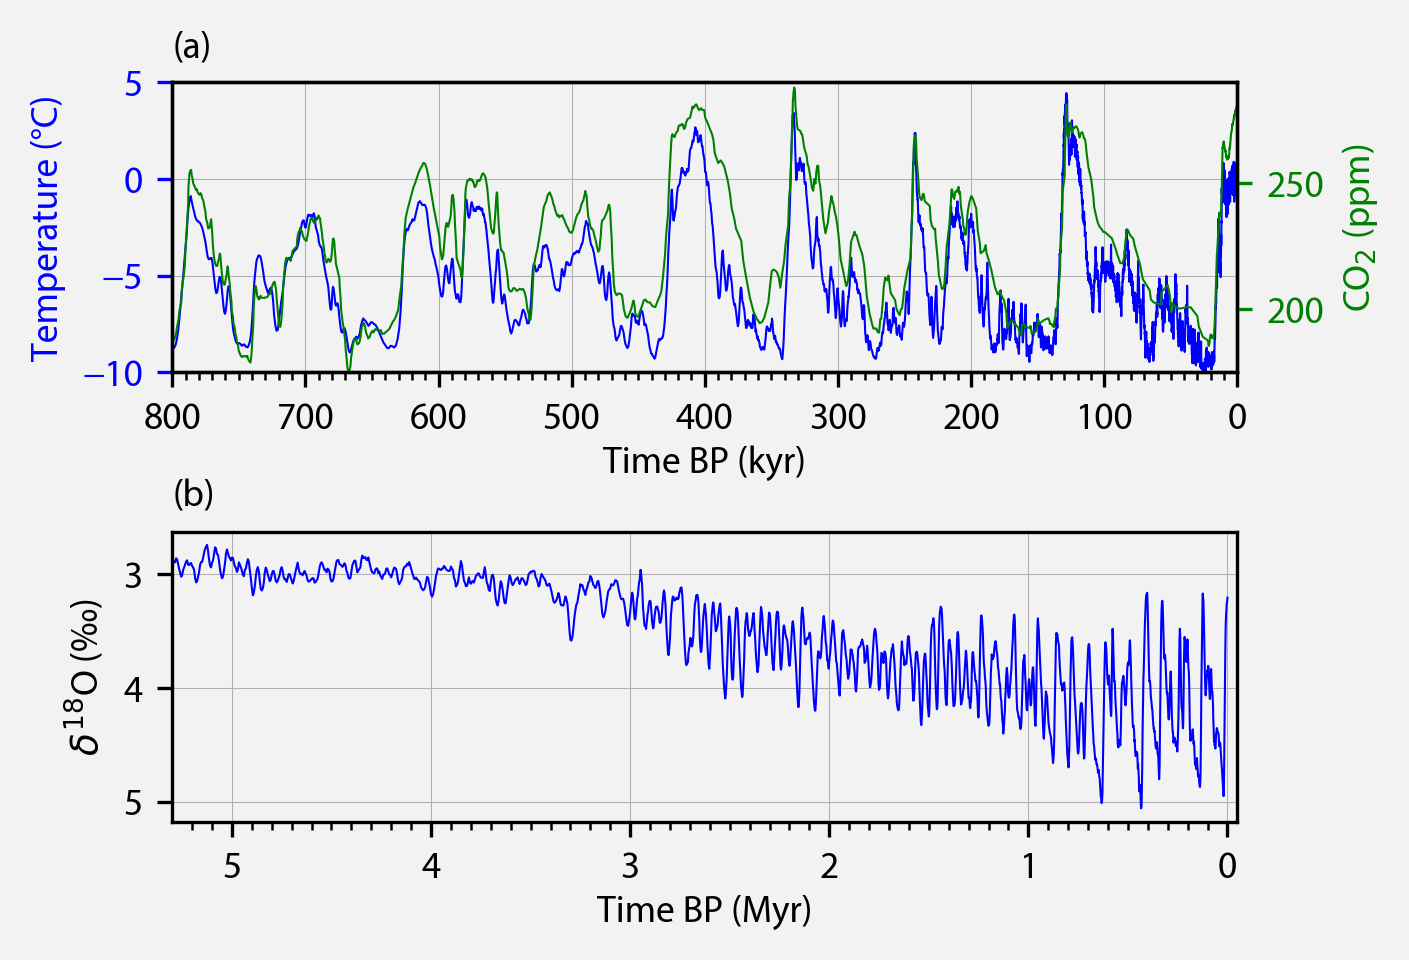

In [3]:
# plot
# for textboxes with (a), (b) etc:
props = dict(boxstyle='round', edgecolor="wheat", facecolor='wheat', alpha=0.9)

fig=plt.figure(figsize=(4.5,3),dpi=300)

plt.subplot(2,1,1)
plt.plot(Antarctica_temperature_years/1000,Antarctica_temperature_smooth,color='b',lw=0.5)
plt.grid(lw=0.25)
plt.ylabel("Temperature (°C)",color="b")
plt.ylim(-10,5)
ax1=plt.gca()
ax1.tick_params(axis='y', colors='b')
ax1.set_xlabel("Time BP (kyr)",labelpad=2)
ax1.set_xticks(np.arange(0,800,10), minor=True)
ax2=ax1.twinx()
ax2.tick_params(axis='y', colors='g')
ax2.set_ylim(175,290)
ax2.plot(Antarctica_CO2_years/1000,Antarctica_CO2_smooth,color='g',lw=0.5)
ax2.set_ylabel("CO$_2$ (ppm)",color="g")
plt.xlim(0,800)
ax1.invert_xaxis()
ax1.set_facecolor('#f2f2f2')
plt.title("(a)",loc="left",fontsize=fontsize)


plt.subplot(2,1,2)
# East pacific
plt.plot(lisiecki_d18O_years/1000,lisiecki_d18O_smooth,color='b',lw=0.5)
plt.grid(lw=0.25)
axes=plt.gca()
axes.invert_yaxis()
plt.xlim(-0.05,5.300)
#plt.ylim(24,29.3)
axes.set_xticks(np.arange(0,5.300,.100), minor=True)
#plt.gca().set_yticks(np.arange(20,33,1), minor=True)
axes.invert_xaxis()
plt.xlabel("Time BP (Myr)",labelpad=2)
plt.ylabel("$\delta^{18}$O (‰)")
axes.set_facecolor('#f2f2f2')
plt.title("(b)",loc="left",fontsize=fontsize)


fig.patch.set_facecolor('#f2f2f2')

plt.tight_layout(pad=0)
plt.subplots_adjust(hspace=0.55)
plt.show()
fig.savefig("Output/Box-ice-ages.pdf",facecolor='#f2f2f2')